## Imports

In [104]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
from scipy.spatial.distance import cdist

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import (
    EVENTSEG_EDGECOLOR, 
    FIG_DIR,
    HEATMAP_CMAP, 
    PROCESSED_DIR
)
from analysis_helpers.functions import (
    draw_event_bounds, 
    mean_center, 
    show_source
)

## Functions

In [27]:
show_source(draw_event_bounds)

In [2]:
show_source(mean_center)

In [3]:
def smooth_trajectory(traj, window):
    return pd.DataFrame(traj).rolling(window).mean().loc[window:, :].to_numpy()

In [4]:
def plot_2d_traj(ax, traj, cmap, linewidth=None):
    if linewidth is None:
        linewidth = plt.rcParams['lines.linewidth']
        
    points = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lines = LineCollection(segments, cmap=cmap)
    cmap_samples = np.linspace(0, 1, len(segments))
    lines.set_array(cmap_samples)
    lines.set_linewidth(linewidth)
    ax.add_collection(lines)
    ax.autoscale()
    return ax

## Load data

In [5]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

reducer = pickle.loads((PROCESSED_DIR / 'umap_reducer.p').read_bytes())

## Create 2D trajectory projections

In [6]:
EXAMPLE_PARTICIPANT_N = 50

EPISODE_SMOOTH_WINDOW = 50
IMM_REC_SMOOTH_WINDOW = 10
DEL_REC_SMOOTH_WINDOW = 10

example_participant = participants[EXAMPLE_PARTICIPANT_N - 1]

ep_traj_centered = mean_center(atlep1.trajectory)
(imm_traj_centered, 
 del_traj_centered) = mean_center(example_participant.trajectories['atlep1'], 
                                  example_participant.trajectories['delayed'])

ep_traj_smoothed = smooth_trajectory(ep_traj_centered, EPISODE_SMOOTH_WINDOW)
imm_traj_smoothed = smooth_trajectory(imm_traj_centered, IMM_REC_SMOOTH_WINDOW)
del_traj_smoothed = smooth_trajectory(del_traj_centered, DEL_REC_SMOOTH_WINDOW)

to_embed = [ep_traj_smoothed, imm_traj_smoothed, del_traj_smoothed]
split_inds = np.cumsum([vec.shape[0] for vec in to_embed])[:-1]
stacked_trajs = np.vstack(to_embed)
stacked_embeddings = reducer.transform(stacked_trajs)
ep_traj_2d, imm_traj_2d, del_traj_2d = np.vsplit(stacked_embeddings, split_inds)

## Construct figure

In [ ]:
fig_data = {
    'ep_traj_2d': ep_traj_2d,
    'imm_traj_2d': imm_traj_2d,
    'del_traj_2d': del_traj_2d,
    'ep_events_2d': ep_events_2d,
    'imm_events_2d': imm_events_2d,
    'del_events_2d': del_events_2d,
    'ep_trajectory': atlep1.trajectory,
    'ep_events': atlep1.events,
    'imm_trajectory': example_participant.trajectories['atlep1'],
    'del_trajectory': example_participant.trajectories['delayed'],
    'ep_event_bounds': atlep1.event_bounds,
    'imm_event_bounds': imm_event_bounds,
    'del_event_bounds': del_event_bounds,
    'imm_event_matches': imm_event_matches,
    'del_event_matches': del_event_matches
}

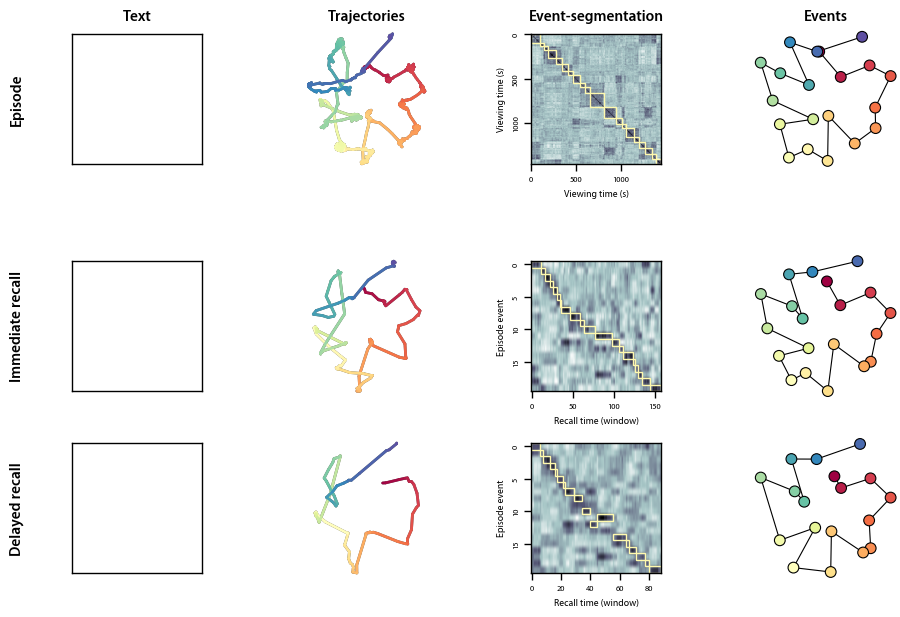

In [125]:
"""
Cleaned, dict-driven refactor of pipeline_fig.py.

Expects a pickled dict `fig_data.p` with these keys (all numpy unless noted):

    # 2D projections (already passed through your fitted UMAP reducer)
    ep_traj_2d      (n_ep_smoothed, 2)
    imm_traj_2d     (n_imm_smoothed, 2)
    del_traj_2d     (n_del_smoothed, 2)
    ep_events_2d    (K, 2)          # atlep1.path_2d
    imm_events_2d   (R_imm, 2)      # paths_2d['atlep1']
    del_events_2d   (R_del, 2)      # paths_2d['delayed']

    # high-dim, for the heatmaps
    ep_trajectory   (T, F)          # atlep1.trajectory
    ep_events       (K, F)          # atlep1.events
    imm_trajectory  (W_imm, F)      # example_participant.trajectories['atlep1']
    del_trajectory  (W_del, F)      # example_participant.trajectories['delayed']

    # bounds (lists of (onset, offset)) + matches (int arrays of episode-event idx)
    ep_event_bounds  (timepoint scale)
    imm_event_bounds, del_event_bounds  (window scale)
    imm_event_matches, del_event_matches

If the file is absent, synthetic stand-ins matching the schema are generated so
the layout/plumbing can be checked without the real data.
"""
from pathlib import Path
import pickle
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import seaborn as sns
from matplotlib.collections import LineCollection
from matplotlib.patches import Rectangle
from scipy.spatial.distance import cdist

# ================================ CONFIG ================================
DATA_PATH = Path("/mnt/user-data/uploads/fig_data.p")

TRAJ_CMAP = plt.cm.Spectral
TRAJ_LINEWIDTH = 2
TRAJ_CASING_COLOR = "0.35"     # dark-gray outline behind the coloured line (None to disable)
TRAJ_CASING_LINEWIDTH = 2    # absolute total width of the casing stroke

HEATMAP_CMAP = plt.cm.bone_r
EVENTSEG_EDGECOLOR = "#FFF9AE"
EVENTSEG_BOUNDS_LINEWIDTH = 1
HEATMAP_LABEL_FONTSIZE = 7
HEATMAP_TICKLABEL_FONTSIZE = 6
HEATMAP_YTICK_ROTATION = 90       # vertical -> uniform ticklabel width -> aligned y-labels
EP_HEATMAP_TICK_INTERVAL = 500    # keep few enough ticks that rotated labels don't overlap

EVENTS_CMAP = plt.cm.Spectral
EVENTS_2D_DOTSIZE = 60
EVENTS_2D_BORDER_LINEWIDTH = 0.8
EVENTS_2D_PATH_LINEWIDTH = 0.8

XY_PAD_2D = 0     # 0 -> the larger (constraining) extent fills the panel edge-to-edge, matching the heatmaps

# layout
FIGSIZE = (11, 7.0)    # wider than tall
GRID_WSPACE = 0.4      # spacing between columns (~2x the default)
GAP_EP_IMM = 0.75      # vertical gap (in row-height units) between episode and immediate rows
GAP_IMM_DEL = 0.4      # smaller gap between the two recall rows

# row / column labels
LABEL_FONTSIZE = 11
LABEL_FONTWEIGHT = "semibold"
COL_TITLE_PAD = 0.015          # figure-fraction gap above the top row
ROW_LABEL_PAD = 0.05           # figure-fraction gap left of the first column
COL_TITLES = ["Text", "Trajectories", "Event-segmentation", "Events"]
ROW_LABELS = ["Episode", "Immediate recall", "Delayed recall"]


# ============================== HELPERS ================================
def mean_center(*to_center, equal_weight=True):
    if len(to_center) == 1:
        return to_center[0] - to_center[0].mean(axis=0)
    input_was_1d = [x.ndim == 1 for x in to_center]
    to_center = [np.atleast_2d(x) for x in to_center]
    if equal_weight:
        mean_centroid = np.mean([x.mean(axis=0) for x in to_center], axis=0)
        centered = [x - mean_centroid for x in to_center]
    else:
        split_inds = np.cumsum([x.shape[0] for x in to_center])[:-1]
        stacked = np.vstack(to_center) - np.vstack(to_center).mean(axis=0)
        centered = np.vsplit(stacked, split_inds)
    return tuple(c[0] if w else c for c, w in zip(centered, input_was_1d))


def draw_event_bounds(ax, event_bounds, edgecolor=EVENTSEG_EDGECOLOR,
                      facecolor="none", **rect_kwargs: Any):
    patches = []
    for onset, offset in event_bounds:
        size = offset - onset + 1
        rect = Rectangle((onset - 0.5, onset - 0.5), width=size, height=size,
                         edgecolor=edgecolor, facecolor=facecolor, **rect_kwargs)
        ax.add_patch(rect)
        patches.append(rect)
    return patches


def plot_2d_traj(ax, traj, cmap, linewidth=TRAJ_LINEWIDTH):
    points = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lines = LineCollection(segments, cmap=cmap)
    lines.set_array(np.linspace(0, 1, len(segments)))
    lines.set_linewidth(linewidth)
    lines.set_capstyle("round")
    lines.set_clip_on(False)
    if TRAJ_CASING_COLOR is not None:
        lines.set_path_effects([pe.Stroke(linewidth=TRAJ_CASING_LINEWIDTH,
                                          foreground=TRAJ_CASING_COLOR, 
                                          capstyle="round"),
                                pe.Normal()])
    ax.add_collection(lines)
    ax.autoscale()
    return ax


def draw_recall_seg(ax, recall_traj, ep_events, event_bounds, event_matches):
    cosmat = 1 - cdist(mean_center(recall_traj), mean_center(ep_events), "cosine")  # W x K
    aspect_ratio = cosmat.shape[0] / cosmat.shape[1]
    ax.imshow(cosmat.T, cmap=HEATMAP_CMAP, aspect=aspect_ratio)
    for (onset, offset), match_ix in zip(event_bounds, event_matches):
        ax.add_patch(Rectangle((onset - 0.5, match_ix - 0.5),
                               width=offset - onset + 1, height=1,
                               linewidth=EVENTSEG_BOUNDS_LINEWIDTH,
                               edgecolor=EVENTSEG_EDGECOLOR, facecolor="none"))
    ax.set_xlabel("Recall time (window)")
    ax.set_ylabel("Episode event")


def draw_events_2d(ax, events_2d, colors):
    ax.plot(events_2d[:, 0], events_2d[:, 1], c="k", alpha=1,
            lw=EVENTS_2D_PATH_LINEWIDTH, zorder=1, clip_on=False)
    ax.scatter(events_2d[:, 0], events_2d[:, 1], s=EVENTS_2D_DOTSIZE, c=colors,
               cmap=EVENTS_CMAP if np.ndim(colors) == 1 else None,
               edgecolors="k", linewidths=EVENTS_2D_BORDER_LINEWIDTH, zorder=2,
               clip_on=False)
    square_2d(ax, events_2d)


def square_2d(ax, pts):
    # frame this panel to its own data with equal x/y spans (undistorted) + square box
    (xmin, ymin), (xmax, ymax) = pts.min(0), pts.max(0)
    cx, cy = (xmin + xmax) / 2, (ymin + ymax) / 2
    half = max(xmax - xmin, ymax - ymin) / 2 + XY_PAD_2D
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy - half, cy + half)
    ax.set_box_aspect(1)
    ax.axis("off")


def style_heatmap(ax):
    ax.xaxis.label.set_size(HEATMAP_LABEL_FONTSIZE)
    ax.yaxis.label.set_size(HEATMAP_LABEL_FONTSIZE)
    ax.tick_params(labelsize=HEATMAP_TICKLABEL_FONTSIZE)
    plt.setp(ax.get_yticklabels(), rotation=HEATMAP_YTICK_ROTATION, va="center")
    ax.set_box_aspect(1)


# =============================== DATA ==================================
def synthetic():
    rng = np.random.default_rng(0)
    F, T, Wi, Wd, K = 768, 1455, 199, 155, 20
    def walk(n):
        step = rng.normal(scale=0.4, size=(n, 2)); return np.cumsum(step, 0)
    def bounds_matches(W, K, drop):
        edges = np.sort(rng.choice(range(5, W - 5), K - 2, replace=False))
        b = list(zip([0, *edges], [*(edges - 1), W - 1]))
        matches = [k for k in range(K) if k != drop][:len(b)]
        return b, np.array(matches)
    imm_b, imm_m = bounds_matches(Wi, K, 6)
    del_b, del_m = bounds_matches(Wd, K, 6)
    ep_edges = np.sort(rng.choice(range(20, T - 20), K - 1, replace=False))
    ep_b = list(zip([0, *ep_edges], [*(ep_edges - 1), T - 1]))
    return dict(
        ep_traj_2d=walk(T - 50), imm_traj_2d=walk(Wi - 10), del_traj_2d=walk(Wd - 10),
        ep_events_2d=walk(K), imm_events_2d=walk(len(imm_m)), del_events_2d=walk(len(del_m)),
        ep_trajectory=rng.normal(size=(T, F)), ep_events=rng.normal(size=(K, F)),
        imm_trajectory=rng.normal(size=(Wi, F)), del_trajectory=rng.normal(size=(Wd, F)),
        ep_event_bounds=ep_b, imm_event_bounds=imm_b, del_event_bounds=del_b,
        imm_event_matches=imm_m, del_event_matches=del_m)

D = fig_data
# D = pickle.loads(DATA_PATH.read_bytes()) if DATA_PATH.exists() else synthetic()
# K = len(D["ep_events_2d"])


# ============================== FIGURE =================================
with sns.plotting_context("paper"):
    fig = plt.figure(figsize=FIGSIZE)
    gs = fig.add_gridspec(5, 4, wspace=GRID_WSPACE, hspace=0.0,
                          height_ratios=[1, GAP_EP_IMM, 1, GAP_IMM_DEL, 1])
    axarr = np.array([[fig.add_subplot(gs[r, c]) for c in range(4)]
                      for r in (0, 2, 4)], dtype=object)
    (row_ep, row_imm, row_del) = axarr

    # --- placeholder column (col 0): reserved for annotation / transcript text ---
    for ax in axarr[:, 0]:
        ax.set_xticks([]); ax.set_yticks([]); ax.set_box_aspect(1)   # keep spines to show the panel box

    # --- trajectories (col 1) ---
    for ax, key in zip(axarr[:, 1], ("ep_traj_2d", "imm_traj_2d", "del_traj_2d")):
        plot_2d_traj(ax, D[key], cmap=TRAJ_CMAP)
        square_2d(ax, D[key])

    # --- episode correlation matrix (col 2, row 0) ---
    ep_corrmat = np.corrcoef(mean_center(D["ep_trajectory"]))
    row_ep[2].imshow(ep_corrmat, cmap=HEATMAP_CMAP)
    draw_event_bounds(row_ep[2], D["ep_event_bounds"], linewidth=EVENTSEG_BOUNDS_LINEWIDTH)
    row_ep[2].set_xlabel("Viewing time (s)"); row_ep[2].set_ylabel("Viewing time (s)")
    _ep_ticks = np.arange(0, len(ep_corrmat), EP_HEATMAP_TICK_INTERVAL)
    row_ep[2].set_xticks(_ep_ticks); row_ep[2].set_yticks(_ep_ticks)
    style_heatmap(row_ep[2])

    # --- recall grounded-segmentation matrices (col 2, rows 1-2) ---
    draw_recall_seg(row_imm[2], D["imm_trajectory"], D["ep_events"],
                    D["imm_event_bounds"], D["imm_event_matches"])
    draw_recall_seg(row_del[2], D["del_trajectory"], D["ep_events"],
                    D["del_event_bounds"], D["del_event_matches"])
    style_heatmap(row_imm[2]); style_heatmap(row_del[2])

    # --- event paths (col 3) ---
    draw_events_2d(row_ep[3],  D["ep_events_2d"],  np.arange(K))
    draw_events_2d(row_imm[3], D["imm_events_2d"], EVENTS_CMAP(D["imm_event_matches"] / K))
    draw_events_2d(row_del[3], D["del_events_2d"], EVENTS_CMAP(D["del_event_matches"] / K))

    # --- row / column labels ---
    for c, title in enumerate(COL_TITLES):
        p = axarr[0, c].get_position()
        fig.text((p.x0 + p.x1) / 2, p.y1 + COL_TITLE_PAD, title,
                 ha="center", va="bottom",
                 fontsize=LABEL_FONTSIZE, fontweight=LABEL_FONTWEIGHT)
    for r, lab in enumerate(ROW_LABELS):
        p = axarr[r, 0].get_position()
        fig.text(p.x0 - ROW_LABEL_PAD, (p.y0 + p.y1) / 2, lab,
                 ha="center", va="center", rotation=90,
                 fontsize=LABEL_FONTSIZE, fontweight=LABEL_FONTWEIGHT)
        
#     plt.savefig(FIG_DIR / 'pipeline-overview-extras.pdf', bbox_inches='tight')
    plt.show()
    